# 🌾 Smart Farm Yield Prediction System
Gradient Boosting Regressor to predict chickpea yield (grams) from daily sensor readings and cumulative agronomic indicators.

## 1 — Imports & Configuration

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import date, timedelta
from scipy import stats

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

sns.set_theme(style='whitegrid', palette='muted')
PALETTE = sns.color_palette('muted', 12)

# ── Agronomic constants ──────────────────────────────────────
GDD_BASE       = 10.0
GDD_UPPER      = 30.0
GDD_FLOWERING  = 850
GDD_POD_FILL   = 1000
GDD_MATURITY   = 1450
TEMP_OPT_LOW   = 18.0
TEMP_OPT_HIGH  = 29.0
MAX_GROW_DAYS  = 120
SOWING_DATE    = date(2026, 3, 1)

YIELD_FEATURES = [
    'cumulative_gdd', 'cumulative_water', 'cumulative_temp_stress',
    'cumulative_humidity_stress', 'cumulative_light',
    'temp', 'humidity', 'soil', 'light', 'water_level', 'day_number'
]
TARGET = 'yield_grams'

print('Setup complete')

Setup complete


## 2 — Load  Dataset

In [100]:

df = pd.read_csv('farm_commu.csv')
print(f'Real dataset loaded: {df.shape}')

df = df.fillna(0).sort_values('day_number').reset_index(drop=True)
df.head(7)

Real dataset loaded: (96, 18)


,day_number,soil,temp,humidity,light,water_level,pump_time,gdd_daily,cumulative_gdd,cumulative_water,temp_stress_daily,cumulative_temp_stress,humidity_stress_day,cumulative_humidity_stress,cumulative_light,growth_stage,yield_pods,yield_grams
0,1,2278,12.5,89.0,331,95.0,0.0,0.31,0.31,0.0,0.00,0.00,0.50,0.50,993,Vegetative,0,0.0
1,1,2281,11.6,71.2,341,95.0,0.0,0.20,0.51,0.0,0.05,0.05,0.00,0.50,2016,Vegetative,0,0.0
2,1,2212,16.1,69.4,2249,95.0,0.0,0.76,1.28,0.0,0.00,0.05,0.00,0.50,8763,Vegetative,0,0.0
3,1,3250,22.8,41.1,4025,95.0,11.5,1.60,2.88,11.5,0.00,0.05,0.00,0.50,20838,Vegetative,0,0.0
4,1,1150,23.6,44.1,4285,83.5,0.0,1.70,4.58,11.5,0.00,0.05,0.00,0.50,33693,Vegetative,0,0.0
5,1,1420,24.7,35.9,4108,83.5,0.0,1.84,6.41,11.5,0.00,0.05,0.51,1.01,46017,Vegetative,0,0.0
6,1,1680,20.7,69.3,1308,83.5,0.0,1.34,7.75,11.5,0.00,0.05,0.00,1.01,49941,Vegetative,0,0.0


## 3 — Feature Engineering

In [120]:
# GDD
df['gdd_daily']       = df['temp'].apply(lambda t: max(0, min(t, GDD_UPPER) - GDD_BASE))
df['cumulative_gdd']  = df['gdd_daily'].cumsum()

# Water
df['cumulative_water'] = df['pump_time'].cumsum()

# Temperature stress
df['temp_stress_daily']      = df['temp'].apply(
    lambda t: max(0, TEMP_OPT_LOW - t) + max(0, t - TEMP_OPT_HIGH))
df['cumulative_temp_stress'] = df['temp_stress_daily'].cumsum()

# Humidity stress
df['humidity_stress_day']        = (df['humidity'] > 80).astype(int)
df['cumulative_humidity_stress'] = df['humidity_stress_day'].cumsum()

# Light
df['cumulative_light'] = df['light'].cumsum()

# Growth stage
def growth_stage(gdd):
    if gdd < GDD_FLOWERING: return 'Vegetative'
    elif gdd < GDD_POD_FILL: return 'Flowering'
    elif gdd < GDD_MATURITY: return 'Pod Fill'
    else: return 'Mature'

df['growth_stage'] = df['cumulative_gdd'].apply(growth_stage)

# Yield target
soil_score     = (1 - abs(df['soil']      - 1500) / 1500).clip(0, 1)
temp_score     = (1 - abs(df['temp']      - 24)   / 15  ).clip(0, 1)
humidity_score = (1 - abs(df['humidity']  - 60)   / 60  ).clip(0, 1)
light_score    = (df['light'] / 1000).clip(0, 1)
water_score    = (1 - abs(df['pump_time'] - 15)   / 15  ).clip(0, 1)
stress_penalty = (df['cumulative_temp_stress'] / (df['cumulative_temp_stress'].max() + 1)).clip(0, 1)
growth_progress = (df['cumulative_gdd'] / GDD_MATURITY).clip(0, 1)

df['yield_pods'] = (
    2 + soil_score * 4 + temp_score * 5 + humidity_score * 2
    + light_score * 3 + water_score * 5 + growth_progress * 8
    - stress_penalty * 5 + np.random.normal(0, 1.5, len(df))
).clip(1, 30).round(1)

df['yield_grams'] = (
    df['yield_pods'] * 0.6 + np.random.normal(0, 0.5, len(df))
).clip(1, 20).round(2)

print(f'Engineered dataset: {df.shape}')
df[YIELD_FEATURES + [TARGET]].describe().round(2)
df.tail()

Engineered dataset: (96, 18)


,day_number,soil,temp,humidity,light,water_level,pump_time,gdd_daily,cumulative_gdd,cumulative_water,temp_stress_daily,cumulative_temp_stress,humidity_stress_day,cumulative_humidity_stress,cumulative_light,growth_stage,yield_pods,yield_grams
91,12,1430,16.4,66.1,1872,10.0,0.0,6.4,767.5,114.3,1.6,191.1,0,16,183580,Vegetative,12.8,7.91
92,12,1680,25.9,35.8,4020,10.0,0.0,15.9,783.4,114.3,0.0,191.1,0,16,187600,Vegetative,13.7,8.76
93,12,1940,24.5,36.7,4280,10.0,0.0,14.5,797.9,114.3,0.0,191.1,0,16,191880,Vegetative,15.3,9.42
94,12,2210,22.3,43.4,4060,10.0,0.0,12.3,810.2,114.3,0.0,191.1,0,16,195940,Vegetative,13.0,8.41
95,12,2760,12.0,83.9,324,10.0,0.0,2.0,812.2,114.3,6.0,197.1,1,17,196264,Vegetative,7.1,3.83


## 4 — Exploratory Data Analysis

### 4a — Daily Sensor Readings Over the Season

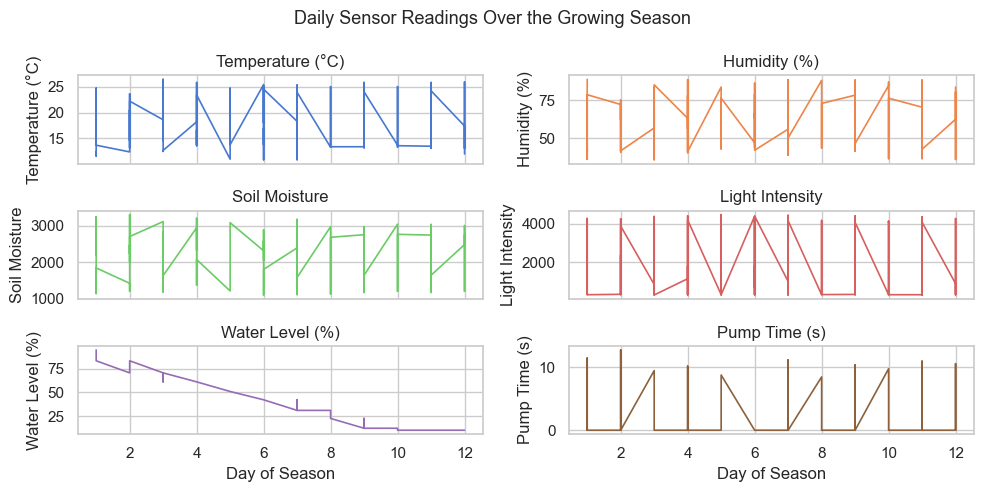

In [127]:
fig, axes = plt.subplots(3, 2, figsize=(10, 5), sharex=True)
axes = axes.flatten()

raw_cols = ['temp', 'humidity', 'soil', 'light', 'water_level', 'pump_time']
titles   = ['Temperature (°C)', 'Humidity (%)', 'Soil Moisture',
            'Light Intensity', 'Water Level (%)', 'Pump Time (s)']

for i, (col, title) in enumerate(zip(raw_cols, titles)):
    axes[i].plot(df['day_number'], df[col], color=PALETTE[i], linewidth=1.2)
    axes[i].set_ylabel(title)
    axes[i].set_title(title)

for ax in axes[-2:]:
    ax.set_xlabel('Day of Season')

plt.suptitle('Daily Sensor Readings Over the Growing Season', fontsize=13)
plt.tight_layout()
plt.show()

### 4b — GDD Accumulation & Growth Stages

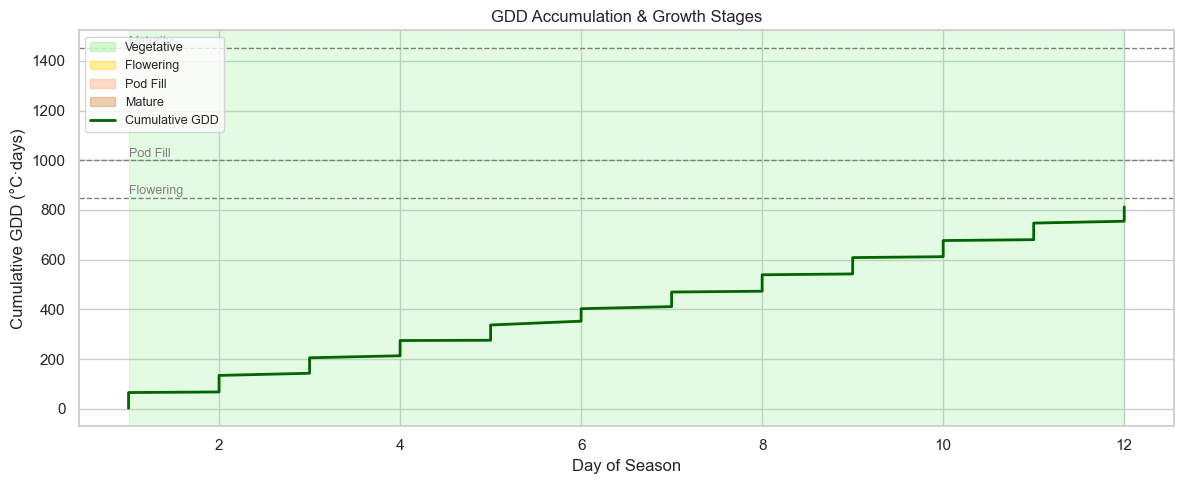

In [103]:
stage_colors = {'Vegetative': '#90EE90', 'Flowering': '#FFD700',
                'Pod Fill': '#FFA07A', 'Mature': '#CD853F'}

fig, ax = plt.subplots(figsize=(12, 5))

# Shade background by growth stage
prev_stage, start_day = df['growth_stage'].iloc[0], df['day_number'].iloc[0]
for _, row in df.iterrows():
    if row['growth_stage'] != prev_stage:
        ax.axvspan(start_day, row['day_number'],
                   alpha=0.25, color=stage_colors[prev_stage], label=prev_stage)
        prev_stage, start_day = row['growth_stage'], row['day_number']
ax.axvspan(start_day, df['day_number'].iloc[-1],
           alpha=0.25, color=stage_colors[prev_stage], label=prev_stage)

ax.plot(df['day_number'], df['cumulative_gdd'], color='darkgreen', linewidth=2, label='Cumulative GDD')
for threshold, name in [(GDD_FLOWERING, 'Flowering'), (GDD_POD_FILL, 'Pod Fill'), (GDD_MATURITY, 'Maturity')]:
    ax.axhline(threshold, color='gray', linestyle='--', linewidth=1)
    ax.text(1, threshold + 15, name, fontsize=9, color='gray')

handles = [mpatches.Patch(color=c, alpha=0.4, label=s) for s, c in stage_colors.items()]
handles.append(plt.Line2D([0], [0], color='darkgreen', linewidth=2, label='Cumulative GDD'))
ax.legend(handles=handles, loc='upper left', fontsize=9)
ax.set_xlabel('Day of Season')
ax.set_ylabel('Cumulative GDD (°C·days)')
ax.set_title('GDD Accumulation & Growth Stages')
plt.tight_layout()
plt.show()

### 4c — Cumulative Stress Indicators

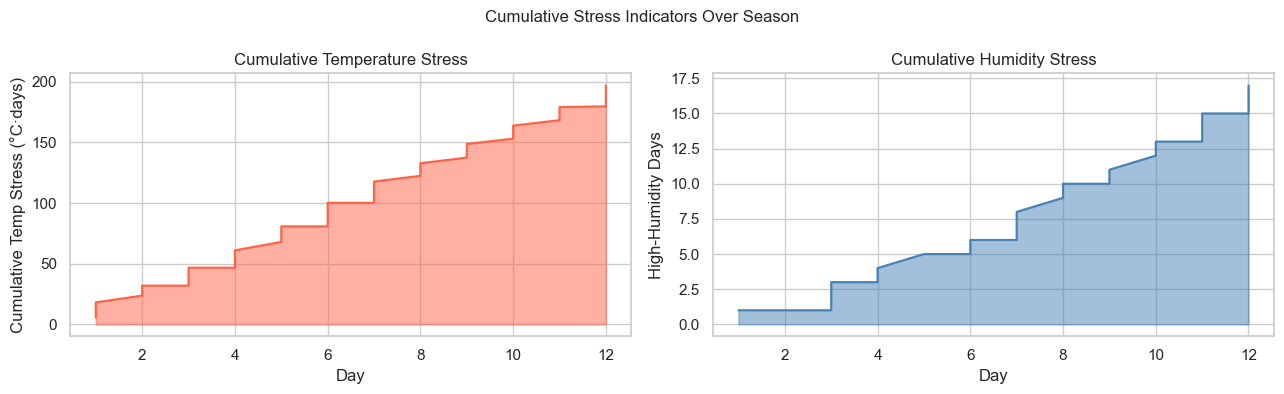

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].fill_between(df['day_number'], df['cumulative_temp_stress'],
                     alpha=0.5, color='tomato')
axes[0].plot(df['day_number'], df['cumulative_temp_stress'], color='tomato', linewidth=1.5)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Cumulative Temp Stress (°C·days)')
axes[0].set_title('Cumulative Temperature Stress')

axes[1].fill_between(df['day_number'], df['cumulative_humidity_stress'],
                     alpha=0.5, color='steelblue')
axes[1].plot(df['day_number'], df['cumulative_humidity_stress'], color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('High-Humidity Days')
axes[1].set_title('Cumulative Humidity Stress')

plt.suptitle('Cumulative Stress Indicators Over Season', fontsize=12)
plt.tight_layout()
plt.show()

### 4d — Yield Over the Season

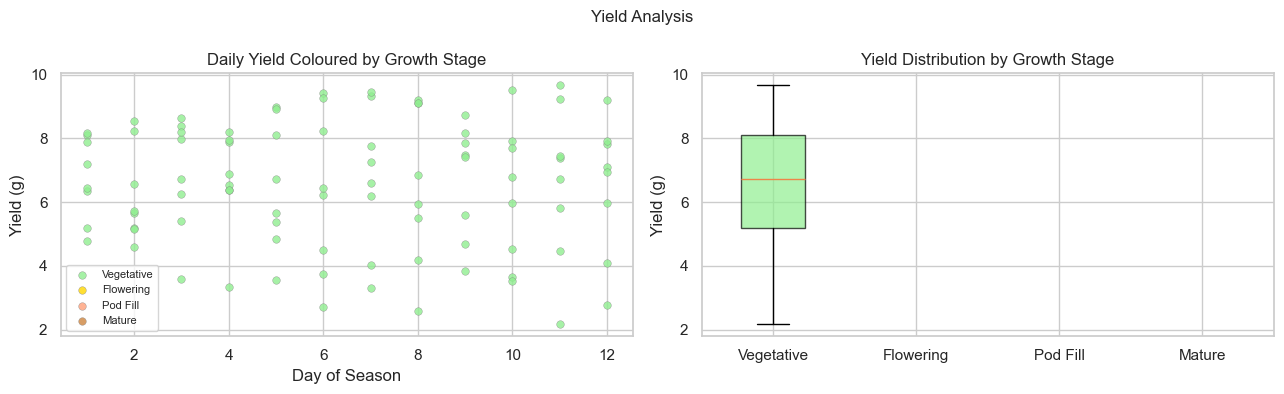

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Yield per day coloured by growth stage
stage_order = ['Vegetative', 'Flowering', 'Pod Fill', 'Mature']
for stage in stage_order:
    mask = df['growth_stage'] == stage
    axes[0].scatter(df.loc[mask, 'day_number'], df.loc[mask, 'yield_grams'],
                    color=stage_colors[stage], s=30, alpha=0.8, label=stage, edgecolors='grey', linewidths=0.3)
axes[0].set_xlabel('Day of Season')
axes[0].set_ylabel('Yield (g)')
axes[0].set_title('Daily Yield Coloured by Growth Stage')
axes[0].legend(fontsize=8)

# Yield distribution per stage
data_by_stage = [df.loc[df['growth_stage'] == s, 'yield_grams'].values for s in stage_order]
bp = axes[1].boxplot(data_by_stage, labels=stage_order, patch_artist=True)
for patch, stage in zip(bp['boxes'], stage_order):
    patch.set_facecolor(stage_colors[stage])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Yield (g)')
axes[1].set_title('Yield Distribution by Growth Stage')

plt.suptitle('Yield Analysis', fontsize=12)
plt.tight_layout()
plt.show()

### 4e — Correlation Heatmap

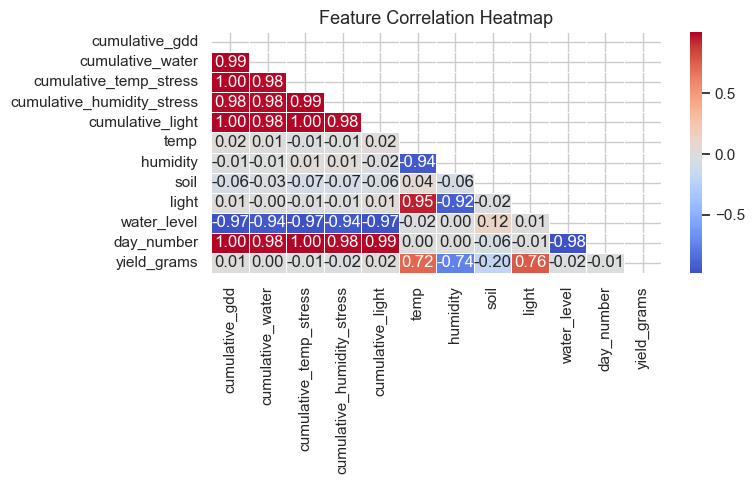

In [130]:
corr = df[YIELD_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Train / Test Split & Scaling

In [107]:
X = df[YIELD_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (76, 11)  |  Test: (20, 11)


## 6 — Train Model

In [108]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
model.fit(X_train_sc, y_train)
print('Training complete')

Training complete


## 7 — Evaluation Metrics

In [109]:
pred      = model.predict(X_test_sc)
mae       = mean_absolute_error(y_test, pred)
r2        = r2_score(y_test, pred)
residuals = y_test.values - pred
rmse      = np.sqrt(np.mean(residuals**2))

print(f'MAE  : {mae:.2f} g')
print(f'RMSE : {rmse:.2f} g')
print(f'R²   : {r2:.4f}')

MAE  : 1.04 g
RMSE : 1.56 g
R²   : 0.2430


## 8 — Prediction Analysis Plots

### 8a — Actual vs Predicted

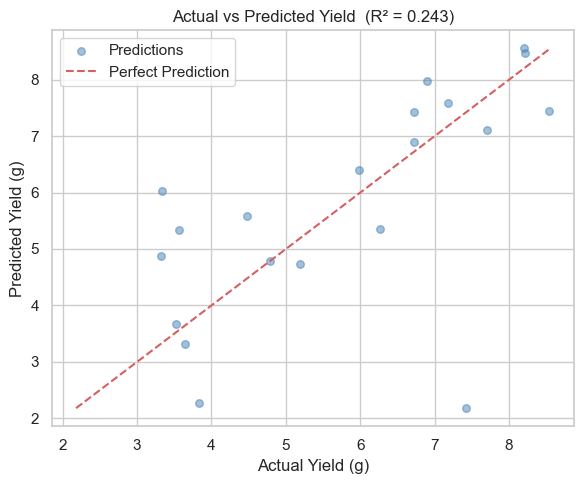

In [131]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, pred, alpha=0.5, s=30, color='steelblue', label='Predictions')
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Yield (g)')
ax.set_ylabel('Predicted Yield (g)')
ax.set_title(f'Actual vs Predicted Yield  (R² = {r2:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

### 8b — Residuals Analysis

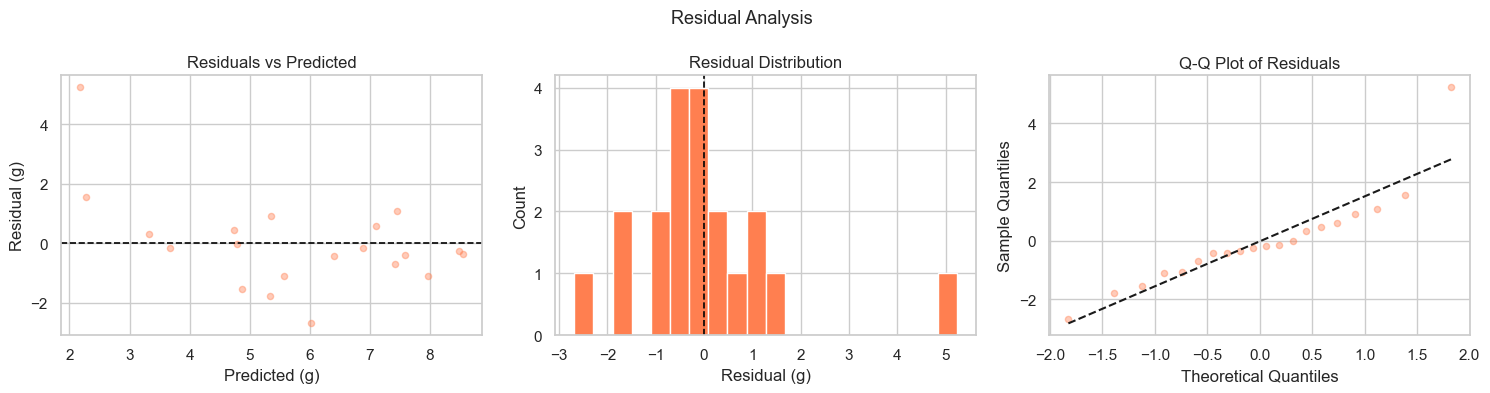

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(pred, residuals, alpha=0.4, s=20, color='coral')
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted (g)')
axes[0].set_ylabel('Residual (g)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residual (g)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

(osm, osr), (slope, intercept, _) = stats.probplot(residuals)
axes[2].scatter(osm, osr, alpha=0.4, s=20, color='coral')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=1.5)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## 9 — Feature Importance

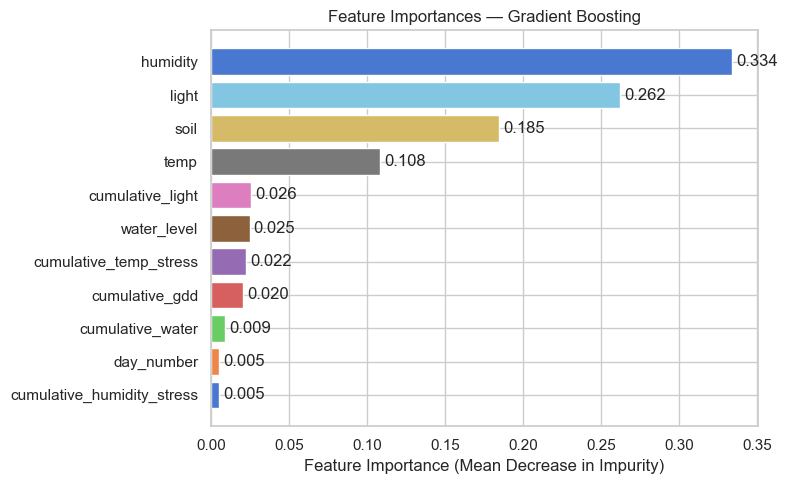

In [132]:
importances = model.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    [YIELD_FEATURES[i] for i in idx],
    importances[idx],
    color=sns.color_palette('muted', len(YIELD_FEATURES))
)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Feature Importances — Gradient Boosting')
plt.tight_layout()
plt.show()

## 10 — Learning Curve

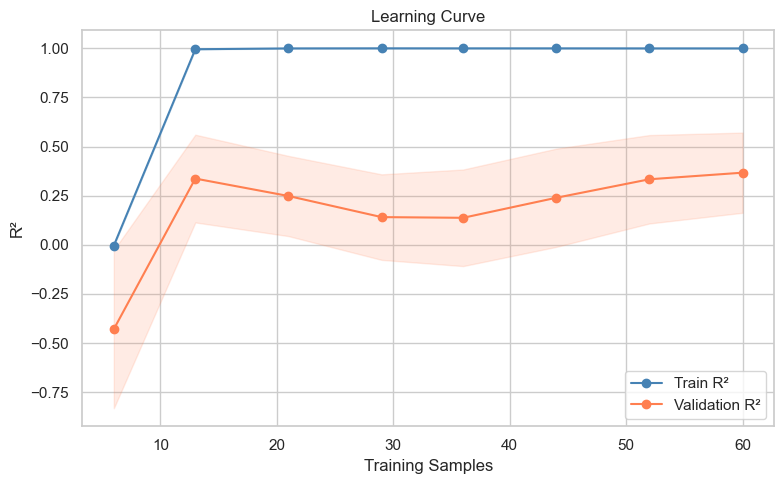

In [113]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_sc, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

t_mean, t_std = train_scores.mean(1), train_scores.std(1)
v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, t_mean, 'o-', label='Train R²',      color='steelblue')
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, v_mean, 'o-', label='Validation R²', color='coral')
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='coral')
ax.set_xlabel('Training Samples')
ax.set_ylabel('R²')
ax.set_title('Learning Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 11 — Boosting: Training Loss Curve

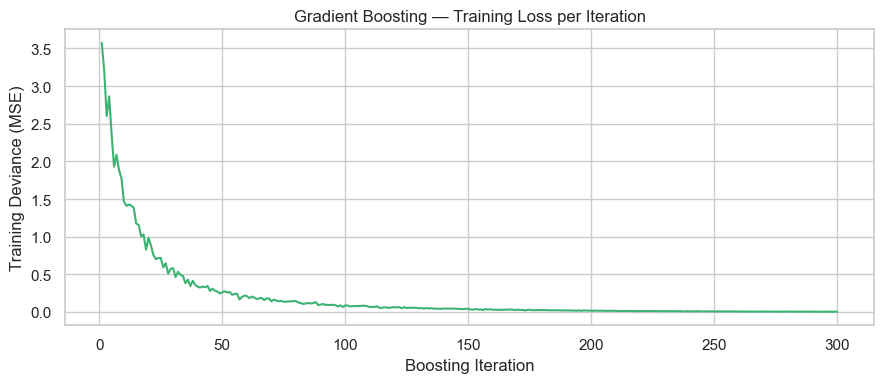

In [114]:
# GradientBoostingRegressor exposes per-iteration train deviance
train_deviance = model.train_score_

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(len(train_deviance)) + 1, train_deviance,
        color='mediumseagreen', linewidth=1.5)
ax.set_xlabel('Boosting Iteration')
ax.set_ylabel('Training Deviance (MSE)')
ax.set_title('Gradient Boosting — Training Loss per Iteration')
plt.tight_layout()
plt.show()

## 12 — Prediction Error Distribution

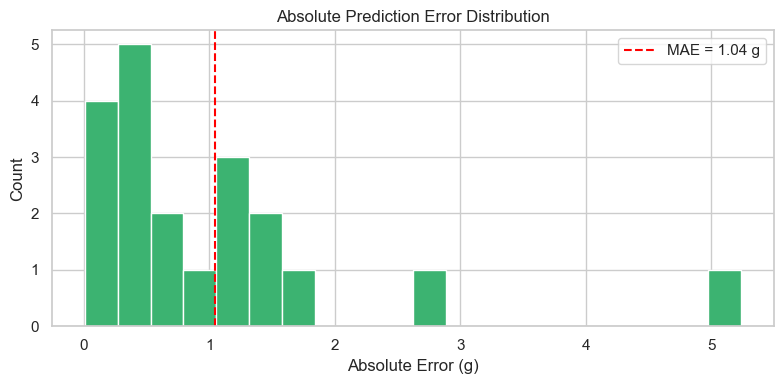

Errors within 0.5 g : 45.0%
Errors within 1.0 g : 60.0%
Errors within 2.0 g : 90.0%


In [115]:
abs_err = np.abs(residuals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(abs_err, bins=20, color='mediumseagreen', edgecolor='white')
ax.axvline(mae, color='red', linestyle='--', linewidth=1.5, label=f'MAE = {mae:.2f} g')
ax.set_xlabel('Absolute Error (g)')
ax.set_ylabel('Count')
ax.set_title('Absolute Prediction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Errors within 0.5 g : {(abs_err <= 0.5).mean()*100:.1f}%')
print(f'Errors within 1.0 g : {(abs_err <= 1.0).mean()*100:.1f}%')
print(f'Errors within 2.0 g : {(abs_err <= 2.0).mean()*100:.1f}%')

## 13 — Save Model

In [116]:
joblib.dump(model,  'yield_model_last2.pkl')
joblib.dump(scaler, 'yield_scaler_last2.pkl')
print('Saved: yield_model_last2.pkl')
print('Saved: yield_scaler_last2.pkl')

Saved: yield_model_last2.pkl
Saved: yield_scaler_last2.pkl


## 14 — Predict Function & Test

In [122]:
def predict_yield_full(
        cumulative_gdd, cumulative_water, cumulative_temp_stress,
        cumulative_humidity_stress, cumulative_light, day_number,
        temp, humidity, soil, light, water_level):

    stage = growth_stage(cumulative_gdd)
    X_new = pd.DataFrame([{
        'cumulative_gdd': cumulative_gdd, 'cumulative_water': cumulative_water,
        'cumulative_temp_stress': cumulative_temp_stress,
        'cumulative_humidity_stress': cumulative_humidity_stress,
        'cumulative_light': cumulative_light, 'temp': temp,
        'humidity': humidity, 'soil': soil, 'light': light,
        'water_level': water_level, 'day_number': day_number
    }])
    grams = float(np.clip(model.predict(scaler.transform(X_new[YIELD_FEATURES]))[0], 1, 30))
    pods  = grams / 0.6

    avg_gdd_day    = cumulative_gdd / max(day_number, 1)
    remaining_gdd  = max(0, GDD_MATURITY - cumulative_gdd)
    days_remaining = int(np.ceil(remaining_gdd / avg_gdd_day)) if avg_gdd_day > 0 else 999
    harvest_date   = date.today() + timedelta(days=days_remaining)

    print('=' * 58)
    print(f'  Today                 : Day {day_number}')
    print(f'  Growth stage          : {stage}')
    print(f'  Cumulative GDD        : {cumulative_gdd:.0f} / {GDD_MATURITY}')
    print(f'  Days until harvest    : ~{days_remaining} days')
    print(f'  Expected harvest date : {harvest_date}')
    print(f'  Expected yield        : {pods:.0f} pods  →  ~{grams:.1f} g of chickpeas')
    print('=' * 58)

    return {'growth_stage': stage, 'pods': round(pods, 0),
            'grams': round(grams, 2), 'harvest_date': str(harvest_date),
            'days_remaining': days_remaining}


result = predict_yield_full(
    cumulative_gdd=1000, cumulative_water=1300,
    cumulative_temp_stress=15, cumulative_humidity_stress=2,
    cumulative_light=7000, day_number=70,
    temp=25, humidity=58, soil=1400, light=850, water_level=75
)
print(result)

  Today                 : Day 70
  Growth stage          : Pod Fill
  Cumulative GDD        : 1000 / 1450
  Days until harvest    : ~32 days
  Expected harvest date : 2026-07-13
  Expected yield        : 14 pods  →  ~8.5 g of chickpeas
{'growth_stage': 'Pod Fill', 'pods': 14.0, 'grams': 8.5, 'harvest_date': '2026-07-13', 'days_remaining': 32}
